# Can we trust the confidence score?

Every label the model produces comes with a **confidence** — the model saying how
sure it is. If that number were trustworthy, wrong labels would carry low
confidence and we could use it to catch mistakes.

This notebook checks whether that is true.


## How the comparison is set up

The model labels the PDF **line by line**, but the annotation is written in
**paragraphs**. To compare like with like, the lines are put back together first:

```
line  'Sufficient data from those datasets…'   answer.text   conf 0.95
line  'findings described in the Aims…'        answer.text   conf 1.00
line  'about other studies.'                   answer.text   conf 0.80
                          ↓  joined into one item
item  'Sufficient data … about other studies.' answer.text   conf 0.80
```

- **Joining**: neighbouring lines with the same label become one item — exactly what
  the pipeline already does when it builds its output.
- **Confidence of an item**: the **lowest** of its lines. A paragraph is only as
  trustworthy as its shakiest line.
- **Correct or not**: the item is matched to the annotation paragraph it belongs to,
  then we check whether the label agrees.

Everything below is one item per row — the same unit the annotation uses.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dmpbridge.core import paths as P
from dmpbridge.evaluation.evaluate import (
    containment, extract_gold, resolve_old_gt_path, tokenize,
)

MODELS = ['llama3.1:8b', 'gemma4:e4b', 'llama3.3:70b']
EXTRACTOR, SAMPLES = 'pdfplumber', range(1, 11)
pd.set_option('display.max_colwidth', 66)
INK = '#111111'


def join_lines(blocks):
    """Neighbouring lines with the same label become one item.

    The item keeps the LOWEST confidence of the lines that formed it.
    """
    items, cur = [], None
    for b in blocks:
        lab, conf = b.get('label'), float(b.get('confidence', 1.0))
        if cur and cur['label'] == lab:
            cur['text'] += ' ' + b['text']
            cur['confidence'] = min(cur['confidence'], conf)
            cur['lines'] += 1
        else:
            if cur:
                items.append(cur)
            cur = {'label': lab, 'text': b['text'],
                   'confidence': conf, 'lines': 1}
    if cur:
        items.append(cur)
    return items


# One row per item: what the model said, how sure it was, and whether it was right.
rows = []
for n in SAMPLES:
    gold = extract_gold(resolve_old_gt_path(n))
    for m in MODELS:
        blocks = json.loads(P.labeled_path(P.make_tag(m, EXTRACTOR), n)
                            .read_text(encoding='utf-8'))
        for it in join_lines(blocks):
            tok = tokenize(it['text'])
            if len(tok) < 3:
                continue                 # too short to place reliably
            best, true_label = 0.0, None
            for gt, gl in gold:
                c = containment(tok, tokenize(gt))
                if c > best:
                    best, true_label = c, gl
            if best < 0.75:
                continue                 # matches no paragraph — nothing to check
            rows.append({'model': m, 'sample': n, 'lines': it['lines'],
                         'true label': true_label,
                         'model said': it['label'],
                         'confidence': it['confidence'],
                         'correct': it['label'] == true_label,
                         'text': it['text']})

df = pd.DataFrame(rows)
print(f'{len(df)} items checked, across {len(MODELS)} models and 10 documents')


768 items checked, across 3 models and 10 documents


## Step 1 — The worst case: review one document

Rather than a summary, take the single document where confidence misleads most —
the one with the largest number of **wrong items that still claim 0.9 or higher** —
and look at what actually happened in it.


In [2]:
per_doc = (df[~df['correct']].groupby('sample')
           .agg(wrong_items=('correct', 'size'),
                confident_mistakes=('confidence', lambda s: (s >= 0.9).sum()))
           .sort_values('confident_mistakes', ascending=False))
WORST = per_doc.index[0]
display(per_doc.style.background_gradient(cmap='Reds',
                                          subset=['confident_mistakes']))
print(f'worst case: sample{WORST}')


,wrong_items,confident_mistakes
sample,,
5,62,52
9,46,43
3,46,26
2,55,23
10,21,16
8,20,15
1,11,10
6,18,5
7,4,1


worst case: sample5


### Inside that document

Every wrong item, with the confidence the model attached to it. The `lines` column
shows how many PDF lines were joined to form the item.


In [3]:
for m in MODELS:
    bad = (df[(df['sample'] == WORST) & (df['model'] == m) & (~df['correct'])]
           .sort_values('confidence', ascending=False)
           [['confidence', 'true label', 'model said', 'lines', 'text']]
           .reset_index(drop=True))
    n_ok = ((df['sample'] == WORST) & (df['model'] == m) & df['correct']).sum()
    print(f'{m} — {n_ok} right, {len(bad)} wrong')
    if len(bad):
        display(bad.head(8).style
                .background_gradient(cmap='Reds', subset=['confidence'],
                                     vmin=0.5, vmax=1.0)
                .format({'confidence': '{:.2f}'}))
    print()


llama3.1:8b — 38 right, 36 wrong


,confidence,true label,model said,lines,text
0,1.00,answer.text,section.title,1,Scripts and code for analyses: All scripts and code will be archived in supplementary information
1,1.00,answer.text,section.title,2,"POLICIES FOR ACCESS AND SHARING Raw data: Detailed information about how the data were obtained, including detailed contact information"
2,1.00,answer.text,section.title,1,Produced Data: Datasets will be produced in Sections 2.1-2.3 of the proposal. These datasets will be
3,1.00,answer.text,section.title,1,Input data: Available data will be systematically reviewed and downloaded. These data are likely
4,1.00,answer.text,section.title,1,"Scientist spotlight: All scientist spotlight biographies, assignments, and open-access readings will be"
5,1.00,answer.text,section.title,1,Workshop frameworks: Workshop material will be shared with UCSB’s Diversity Committee through
6,0.95,answer.text,question.text,1,"At the end of the project, all shareable data accompanied by the appropriate documentation, metadata, and"
7,0.95,answer.text,question.text,1,"freely build upon, enhance and reuse the works for any purposes without restriction under copyright or"



gemma4:e4b — 21 right, 17 wrong


,confidence,true label,model said,lines,text
0,0.95,answer.text,section.title,1,Input data: Available data will be systematically reviewed and downloaded. These data are likely
1,0.95,answer.text,question.text,1,"At the end of the project, all shareable data accompanied by the appropriate documentation, metadata, and"
2,0.95,answer.text,question.text,3,"The project will result in new sets of data, code, and tools. These outputs include: (a) source code to quality control, collate, and merge datasets, (b) open source models and budgets in R and/or python, and (c) sharable instructional materials (Scientist Spotlight activities and workshop materials)."
3,0.95,answer.text,question.text,3,"documented for reproducibility purposes. The metadata for the codes will include: (1) description of the functions required to operate the analyses; (2) description of input parameters and outputs; and (3) test case, files and plots documenting the expected response of the model (Section 2.1) to a standard set of"
4,0.95,answer.text,section.title,1,Produced Data: Datasets will be produced in Sections 2.1-2.3 of the proposal. These datasets will be
5,0.95,answer.text,question.text,1,"Raw data: Detailed information about how the data were obtained, including detailed contact information"
6,0.95,answer.text,question.text,1,correct attribution to original collectors. All methodological procedures for data quality control and
7,0.95,answer.text,question.text,1,Scripts and code for analyses: All scripts and code will be archived in supplementary information



llama3.3:70b — 19 right, 9 wrong


,confidence,true label,model said,lines,text
0,0.90,answer.text,section.title,1,Produced Data: Datasets will be produced in Sections 2.1-2.3 of the proposal. These datasets will be
1,0.90,answer.text,section.title,1,Workshop frameworks: Workshop material will be shared with UCSB’s Diversity Committee through
2,0.90,answer.text,section.title,1,Input data: Available data will be systematically reviewed and downloaded. These data are likely
3,0.90,answer.text,section.title,1,"Scientist spotlight: All scientist spotlight biographies, assignments, and open-access readings will be"
4,0.90,answer.text,section.title,1,Scripts and code for analyses: All scripts and code will be archived in supplementary information
5,0.80,answer.text,section.description,1,The proposal is separated into three sections.
6,0.60,answer.text,question.text,1,• Section 2.3 integrates research and education through the Scientist Spotlight and Hydrologic
7,0.60,answer.text,question.text,1,• Section 2.2 estimates groundwater components of the water budget (withdrawals and consumption)


Read the `confidence` column down the page. These are the model's **mistakes**, and
most of them are claimed with near-total certainty — the same numbers it attaches to
the items it gets right.

**The single sharpest example in the whole corpus** sits in a different document:


In [4]:
# Items every model got wrong, ranked by the lowest confidence any of them gave.
g = (df.groupby(['sample', 'text'])
       .agg(wrong=('correct', lambda s: (~s).sum()), n=('correct', 'size'),
            lowest_conf=('confidence', 'min')).reset_index())
g = g[(g['wrong'] == g['n']) & (g['n'] == len(MODELS))]

# Several tie at 1.00 — prefer one that appears word for word in the prompt.
from dmpbridge.prompts import SYSTEM_PROMPT
g['in_prompt'] = g['text'].str[:40].apply(lambda t: t in SYSTEM_PROMPT)
worst = g.sort_values(['lowest_conf', 'in_prompt'],
                      ascending=[False, False]).iloc[0]
hit = df[(df['sample'] == worst['sample']) & (df['text'] == worst['text'])]

print(f"sample{worst['sample']}")
print(f"text        : {worst['text'][:96]!r}")
print(f"true label  : {hit['true label'].iloc[0]}")
print(f"this exact text is an example in the system prompt: {worst['in_prompt']}")
print()
display(hit[['model', 'model said', 'confidence']].reset_index(drop=True)
        .style.background_gradient(cmap='Reds', subset=['confidence'],
                                   vmin=0.5, vmax=1.0)
        .format({'confidence': '{:.2f}'}))


sample2
text        : 'Data Types and Sources. A brief, high-level description of the data to be generated or used thro'
true label  : question.text
this exact text is an example in the system prompt: True



,model,model said,confidence
0,llama3.1:8b,section.title,1.00
1,gemma4:e4b,section.title,1.00
2,llama3.3:70b,section.title,1.00


All three models call it a section heading; the annotation says it is a question —
and all three are **completely certain**.

This sentence is written into the system prompt **as the example of what a question
looks like**. The models were shown it with the right label in their instructions,
and still got it wrong at full confidence.


## Step 2 — Is that one item typical?

If confidence worked, the **wrong** column would be clearly lower than the
**right** column.


In [5]:
rows = []
for m in MODELS:
    d = df[df['model'] == m]
    ok, bad = d[d['correct']], d[~d['correct']]
    rows.append({
        'model': m,
        'items right': len(ok),
        'items wrong': len(bad),
        'confidence when RIGHT': ok['confidence'].mean(),
        'confidence when WRONG': bad['confidence'].mean(),
        'wrong items at 0.9 or above': (bad['confidence'] >= 0.9).mean(),
    })
t = pd.DataFrame(rows).set_index('model')
display(t.style
        .background_gradient(cmap='Reds', subset=['wrong items at 0.9 or above'])
        .format({'confidence when RIGHT': '{:.2f}',
                 'confidence when WRONG': '{:.2f}',
                 'wrong items at 0.9 or above': '{:.0%}'}))


,items right,items wrong,confidence when RIGHT,confidence when WRONG,wrong items at 0.9 or above
model,,,,,
llama3.1:8b,214,222,0.89,0.89,64%
gemma4:e4b,117,38,0.96,0.91,74%
llama3.3:70b,133,44,0.88,0.83,48%


The two confidence columns are close together for every model — and for llama3.1:8b
the wrong items are about as confident as the right ones.

The last column is the practical problem: most wrong items still claim 0.9 or more,
so a high score simply does not mean a correct label.


## Step 3 — The same thing as a picture

Green to the right is **right**, red to the left is **wrong**, stacked by
confidence. If confidence worked, the red bars would sit at the **bottom** —
mistakes flagged by low confidence.


saved -> Report-doc\confidence_right_vs_wrong.png


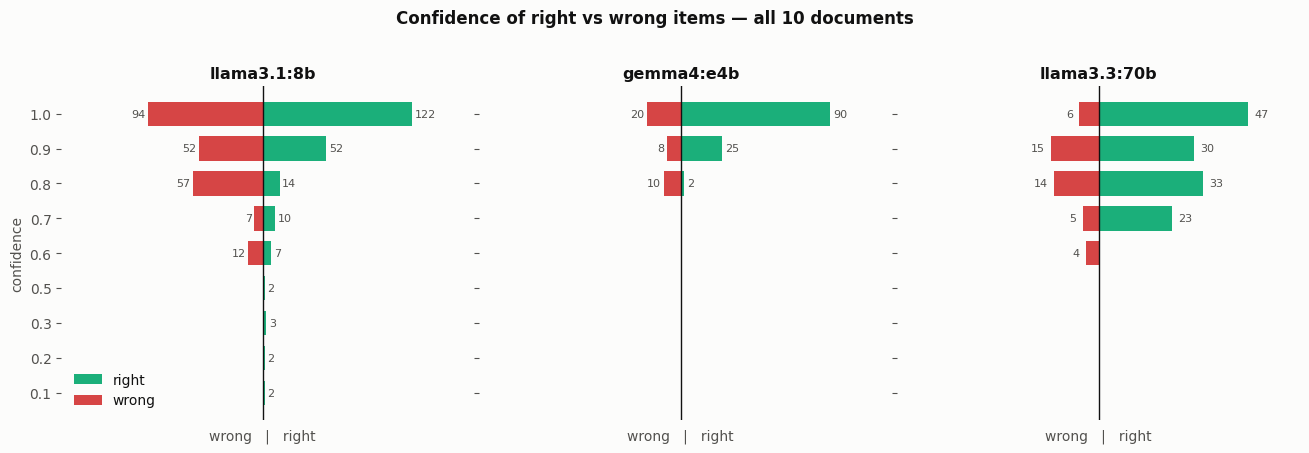

In [6]:
GOOD, BAD = '#1baf7a', '#d64545'
MUTED, SURFACE = '#52514e', '#fcfcfb'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': MUTED,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.titlecolor': INK, 'font.size': 10,
    'axes.titlesize': 11.5, 'axes.titleweight': 'bold', 'legend.frameon': False,
})

df['bin'] = (df['confidence'] * 10).round() / 10
bins = sorted(df['bin'].unique())
y = np.arange(len(bins))

fig, axes = plt.subplots(1, len(MODELS), figsize=(4.4 * len(MODELS), 4.4),
                         sharey=True)
for ax, m in zip(np.atleast_1d(axes), MODELS):
    d = df[df['model'] == m]
    ok = d[d['correct']].groupby('bin').size().reindex(bins, fill_value=0)
    bad = d[~d['correct']].groupby('bin').size().reindex(bins, fill_value=0)
    ax.barh(y, ok.values, color=GOOD, height=0.7, label='right')
    ax.barh(y, -bad.values, color=BAD, height=0.7, label='wrong')
    for yi, (o, b) in enumerate(zip(ok.values, bad.values)):
        if o:
            ax.text(o + 2, yi, str(o), va='center', fontsize=8, color=MUTED)
        if b:
            ax.text(-b - 2, yi, str(b), va='center', ha='right',
                    fontsize=8, color=MUTED)
    ax.axvline(0, color=INK, linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels([f'{b:.1f}' for b in bins])
    lim = max(ok.max(), bad.max()) * 1.35
    ax.set_xlim(-lim, lim)
    ax.set_xticks([])
    ax.set_title(m)
    ax.set_xlabel('wrong   |   right', labelpad=6)
    for side in ('top', 'right', 'left', 'bottom'):
        ax.spines[side].set_visible(False)

np.atleast_1d(axes)[0].set_ylabel('confidence')
np.atleast_1d(axes)[0].legend(loc='lower left')
fig.suptitle('Confidence of right vs wrong items — all 10 documents',
             fontweight='bold', y=1.02)
plt.tight_layout()
out = Path('Report-doc/confidence_right_vs_wrong.png')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor=SURFACE)
print(f'saved -> {out}')
plt.show()


## Conclusion

**The confidence score cannot be used to catch mistakes.**

The red bars sit at the top of the chart, alongside the green ones — wrong items are
about as confident as right ones. The clearest single case is step 1: an item that
all three models label wrongly at **complete certainty**, and which the prompt itself
offers as an example of the correct label.

**What not to do:** never use confidence to accept a label automatically, or to drop
one. A dropped item becomes a missing item, which costs exactly as much as a wrong
one.

**The one thing it might support:** gemma4:e4b is the only model whose wrong items
are noticeably less confident than its right ones, so its lowest-confidence output
could be worth sending to a person to check. Its scale is its own, though — a
threshold picked for gemma4 means nothing for the other two.
